# Peak Demand Timing Analytics and Logistic Regression Model

This notebook helps analyze peak booking demand and build a simple logistic regression model to predict whether an order belongs to a peak-demand period.

## Problem Statement
The business currently lacks visibility into peak booking periods, which may lead to inefficient rider allocation and limited pickup capacity during high-demand windows. This notebook uses time-based analytics to identify peak booking periods and a logistic regression model to predict peak-demand orders.

## Business Objective
- Identify the busiest booking hours
- Understand demand patterns by day of week
- Predict whether an order falls into a peak-demand period
- Support decisions such as increasing pickup slots and allocating more riders during peak periods


## Recommended Features

Used in the model:
- `booking_hour`
- `booking_day_of_week`
- `zone`
- `category`
- `quantity`

Not used in the first model:
- `order_id` (identifier only)
- `order_value_sgd` (better for separate value analysis)
- `processing_days`, `processing_label`, `order_status` (operational outcomes / leakage)
- `delivery_slot` (more useful for downstream fulfillment analysis)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

plt.rcParams['figure.figsize'] = (10, 6)


## 1. Load Data

In [2]:
df = pd.read_csv('../../data1/astoria_orders.csv')
df.columns = df.columns.str.strip().str.lower()

print('Shape:', df.shape)
display(df.head())


Shape: (5000, 27)


,order_id,booking_date,booking_time,booking_hour,booking_day_of_week,collection_date,collection_time,delivery_date,delivery_slot,zone,...,base_price_sgd,delicate_surcharge,express_type,express_multiplier,order_value_sgd,free_delivery,processing_days,processing_label,effort_score,order_status
0,AST-00001,2024-06-07,11:15,11,Friday,2024-06-07,14:46,2024-06-10,15:00-18:00,Choa Chu Kang / Bukit Panjang,...,9,0,NaN,1.0,8.83,No,2,1-2 days,1,Completed
1,AST-00002,2024-03-23,11:24,11,Saturday,2024-03-23,16:07,2024-03-25,15:00-18:00,Buona Vista / Holland,...,18,0,NaN,1.0,35.73,No,2,1-2 days,2,Completed
2,AST-00003,2024-04-19,10:08,10,Friday,2024-04-19,15:55,2024-04-22,12:00-16:00,Choa Chu Kang / Bukit Panjang,...,20,0,Next-day,2.0,117.66,Yes,3,3-6 days,2,Completed
3,AST-00004,2024-08-30,21:25,21,Friday,2024-08-31,11:31,2024-09-04,15:00-18:00,Punggol / Sengkang,...,55,0,NaN,1.0,53.35,Yes,4,3-6 days,3,Completed
4,AST-00005,2024-11-01,10:33,10,Friday,2024-11-01,12:13,2024-11-04,09:00-13:00,Tampines / Pasir Ris,...,30,0,NaN,1.0,29.73,No,3,3-6 days,2,Completed


## 2. Data Cleansing

In [3]:
# Convert date columns if present
date_cols = ['booking_date', 'collection_date', 'delivery_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# Convert likely numeric columns
numeric_cols = [
    'booking_hour', 'quantity', 'base_price_sgd', 'delicate_surcharge',
    'express_multiplier', 'order_value_sgd', 'processing_days',
    'effort_score', 'latitude', 'longitude'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)


order_id                       object
booking_date           datetime64[ns]
booking_time                   object
booking_hour                    int64
booking_day_of_week            object
collection_date        datetime64[ns]
collection_time                object
delivery_date          datetime64[ns]
delivery_slot                  object
zone                           object
postal_district                object
postal_code                     int64
latitude                      float64
longitude                     float64
service                        object
category                       object
quantity                        int64
base_price_sgd                  int64
delicate_surcharge              int64
express_type                   object
express_multiplier            float64
order_value_sgd               float64
free_delivery                  object
processing_days                 int64
processing_label               object
effort_score                    int64
order_status

## 3. Analytics: Peak Demand by Booking Hour

,booking_hour,order_count
0,0,33
1,1,61
2,2,49
3,3,55
4,4,48
5,5,47
6,6,52
7,7,46
8,8,361
9,9,335


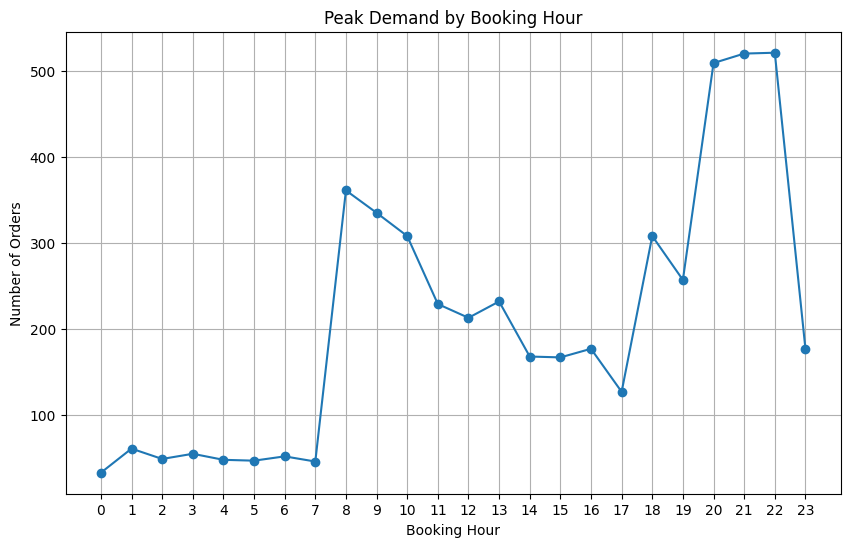

In [4]:
hourly = df.groupby('booking_hour')['order_id'].count().reset_index()
hourly.columns = ['booking_hour', 'order_count']
hourly = hourly.sort_values('booking_hour')

display(hourly)

plt.plot(hourly['booking_hour'], hourly['order_count'], marker='o')
plt.title('Peak Demand by Booking Hour')
plt.xlabel('Booking Hour')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


## 4. Analytics: Demand by Day of Week

,booking_day_of_week,order_count
1,Monday,823
4,Tuesday,815
5,Wednesday,820
3,Thursday,823
0,Friday,875
2,Saturday,844


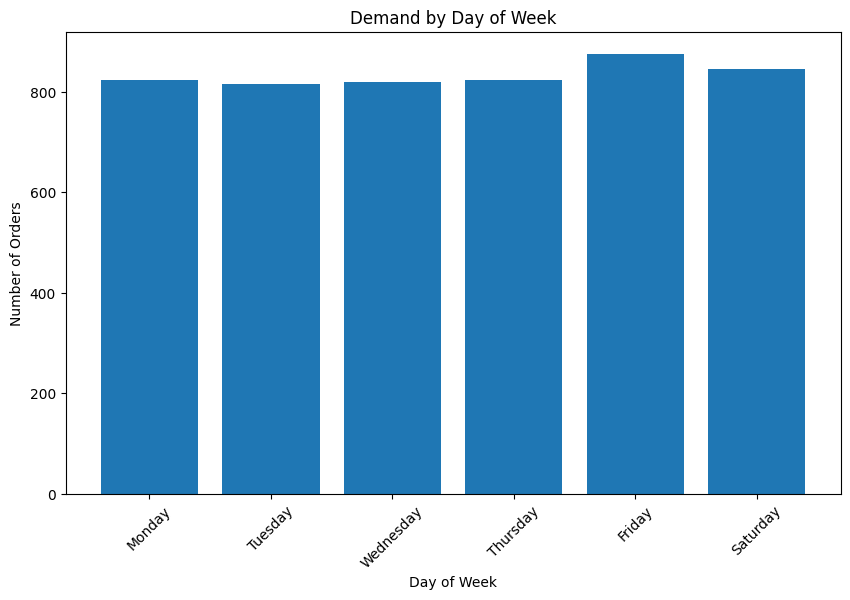

In [5]:
dow = df.groupby('booking_day_of_week')['order_id'].count().reset_index()
dow.columns = ['booking_day_of_week', 'order_count']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow['booking_day_of_week'] = pd.Categorical(dow['booking_day_of_week'], categories=day_order, ordered=True)
dow = dow.sort_values('booking_day_of_week')

display(dow)

plt.bar(dow['booking_day_of_week'], dow['order_count'])
plt.title('Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()


Demand is relatively consistent throughout the week, with a slight increase on Fridays. This suggests that demand is not heavily dependent on specific weekdays, but rather driven by time-of-day behaviour.

## 5. Create Peak Demand Label

We define peak-demand hours as the **top 25% busiest booking hours**.

In [6]:
threshold = hourly['order_count'].quantile(0.75)
peak_hours = hourly.loc[hourly['order_count'] >= threshold, 'booking_hour'].tolist()

df['is_peak'] = df['booking_hour'].isin(peak_hours).astype(int)

print('Peak threshold:', threshold)
print('Peak hours identified:', peak_hours)
print('\nClass distribution:')
print(df['is_peak'].value_counts())
print('\nClass proportion:')
print(df['is_peak'].value_counts(normalize=True))


Peak threshold: 308.0
Peak hours identified: [8, 9, 10, 18, 20, 21, 22]

Class distribution:
is_peak
1    2862
0    2138
Name: count, dtype: int64

Class proportion:
is_peak
1    0.5724
0    0.4276
Name: proportion, dtype: float64


Peak demand occurs during early morning (8–10 AM) and evening hours (6–10 PM), showing that customers place orders before and after work hours.

## 6. Build Logistic Regression Model

In [7]:
selected_features = ['booking_hour', 'booking_day_of_week', 'zone', 'category', 'quantity']
selected_features = [col for col in selected_features if col in df.columns]

X = df[selected_features].copy()
y = df['is_peak'].copy()

# Fill missing values simply for this first model
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna('Unknown')

for col in X.select_dtypes(include=['number']).columns:
    X[col] = X[col].fillna(X[col].median())

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.633

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.61      0.59       428
           1       0.69      0.65      0.67       572

    accuracy                           0.63      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.64      0.63      0.63      1000

Confusion Matrix:
[[260 168]
 [199 373]]


Model Performance: 
The logistic regression model achieved an accuracy of 63.3%, indicating a moderate ability to predict peak demand orders. This is acceptable given the variability in customer booking behaviour.

Classification Performance:
The model shows balanced performance, with recall of 65% for peak orders and 61% for non-peak orders, indicating it can reasonably distinguish between high- and low-demand periods.

Confusion Matrix Interpretation:
The model correctly classified 260 non-peak and 373 peak orders, with some misclassification expected due to unpredictable customer behaviour.

Key Insight:
Overall, the model provides reliable demand insights that can support operational decisions. The business can use these predictions to increase pickup slots and allocate more riders during peak periods, improving efficiency and customer satisfaction.

## 7. Feature Coefficients
Positive coefficients suggest higher likelihood of peak demand.

In [8]:
coef_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

display(coef_df.head(15))
display(coef_df.tail(15))


,feature,coefficient
30,category_On-site,0.350950
9,zone_Boon Lay / Tuas,0.297034
32,category_Traditional,0.242012
21,zone_Queenstown / Alexandra,0.220921
28,category_Clothing,0.202327
23,zone_Tampines / Pasir Ris,0.184355
18,zone_Novena / Newton,0.179235
7,zone_Bedok / Chai Chee,0.168144
16,zone_Jurong East / West,0.155818
8,zone_Bishan / Toa Payoh,0.127938


,feature,coefficient
2,booking_day_of_week_Monday,0.012316
1,quantity,0.006109
27,category_Bags & Shoes,-0.000135
11,zone_Buona Vista / Holland,-0.019902
6,booking_day_of_week_Wednesday,-0.024371
5,booking_day_of_week_Tuesday,-0.052751
3,booking_day_of_week_Saturday,-0.069207
31,category_Special,-0.091173
19,zone_Orchard / River Valley,-0.096035
20,zone_Punggol / Sengkang,-0.137703


Feature Insights
1. Positive drivers (increase likelihood of peak demand):
- Service categories such as On-site, Traditional, and Clothing are more likely to occur during peak periods.
This suggests that certain service types are more frequently requested during high-demand time windows.
- Location also plays a role, with zones such as Boon Lay / Tuas, Queenstown, and Tampines showing higher peak demand activity.
As expected, booking hour remains an important factor, reinforcing the influence of time-based behaviour.

2. Negative drivers (lower likelihood of peak demand):
- Zones such as Woodlands / Marsiling, Geylang / Eunos, and Choa Chu Kang are associated with lower peak demand probability.
This indicates that these areas tend to exhibit more off-peak demand patterns.

## 8. Summary 

Key Insights: 
- Demand peaks during early morning (8–10 AM) and evening hours (6–10 PM), reflecting pre-work and post-work customer behaviour.
- Demand is relatively consistent across weekdays, with a slight increase observed on Fridays, indicating stable demand patterns rather than strong day-specific spikes.
- The logistic regression model identifies booking hour as a key driver of peak demand, showing the importance of time-based demand patterns.
- Additional factors such as service category and geographic zone also influence peak demand, suggesting that both operational and location-based factors play a role.

Business Recommendations
- Increase pickup slot availability during peak periods (8–10 AM and 6–10 PM)
- Allocate more riders during high-demand time windows to reduce service delays
- Optimise resource distribution across high-demand zones (e.g., Queenstown, Tampines)
- Maintain baseline capacity during non-peak periods to avoid over-allocation

Business Impact
- Faster pickups and improved service responsiveness
- Reduced waiting times during peak periods
- More efficient rider utilisation and scheduling
- Enhanced overall customer satisfaction and service reliability